In [1]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_excel(r'online_retail_II.xlsx',sheet_name="Year 2009-2010")

In [3]:
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
data.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [5]:
data.shape

(525461, 8)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [7]:
data.dropna()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


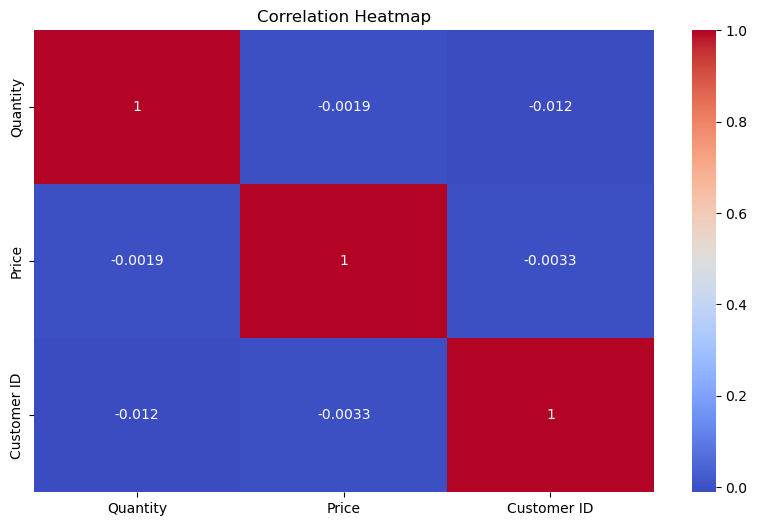

In [8]:
numeric_data = data.select_dtypes(include=['number'])
corr = numeric_data.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

In [9]:
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

In [10]:
data['TotalPrice'] = data['Quantity'] * data['Price']

In [11]:
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [12]:
snapshot_date = data['InvoiceDate'].max() + pd.Timedelta(days=1)

In [14]:
rfm = data.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
})

In [15]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [16]:
print(rfm.head())

             Recency  Frequency  Monetary
Customer ID                              
12346.0           67         15    -64.68
12347.0            3          2   1323.32
12348.0           74          1    222.16
12349.0           43          4   2646.99
12351.0           11          1    300.93


In [17]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    4,
    labels=[4,3,2,1]
)

In [18]:
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

In [19]:
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    4,
    labels=[1,2,3,4]
)

In [20]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

In [21]:
def segment_customer(score):

    if score == '444':
        return 'Champion'

    elif score[0] == '4':
        return 'Loyal Customer'

    elif score[0] == '1':
        return 'At Risk'

    else:
        return 'Regular'


rfm['Segment'] = rfm['RFM_Score'].apply(segment_customer)

In [22]:
print(rfm['Segment'].value_counts())

Segment
Regular           2195
At Risk           1089
Loyal Customer     630
Champion           469
Name: count, dtype: int64


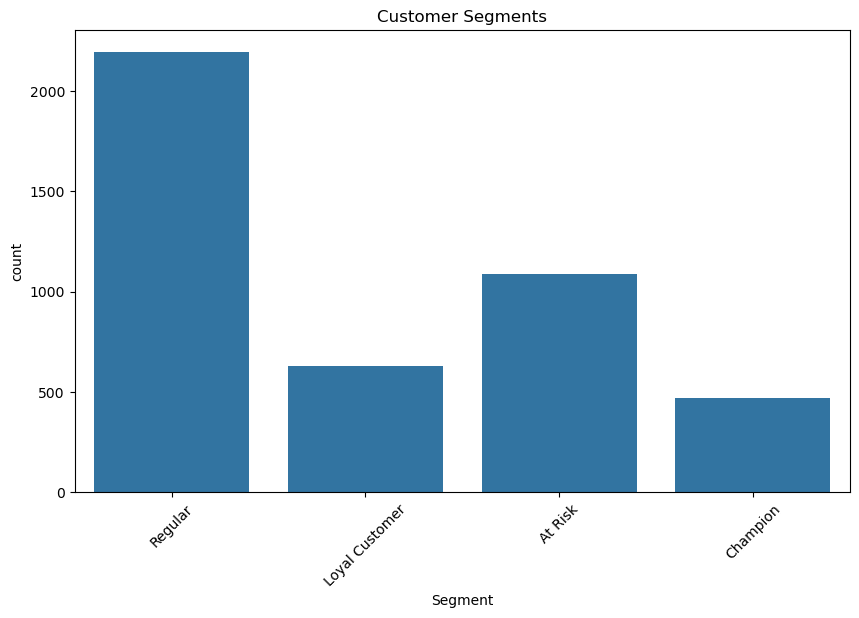

In [23]:
plt.figure(figsize=(10,6))
sns.countplot(x='Segment', data=rfm)
plt.xticks(rotation=45)
plt.title("Customer Segments")
plt.show()

In [27]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
Customer ID,,,,,,,,
12346.0,67,15,-64.68,2,4,1,241,Regular
12347.0,3,2,1323.32,4,2,3,423,Loyal Customer
12348.0,74,1,222.16,2,1,1,211,Regular
12349.0,43,4,2646.99,3,3,4,334,Regular
12351.0,11,1,300.93,4,1,2,412,Loyal Customer


In [28]:
rfm.to_excel('Customer_Seg_Dataset.xlsx')

In [24]:
top_customers = rfm.sort_values(
    by='Monetary',
    ascending=False
)

print(top_customers.head(10))

             Recency  Frequency   Monetary R_Score F_Score M_Score RFM_Score  \
Customer ID                                                                    
18102.0            1         95  341776.73       4       4       4       444   
14646.0           10         87  243853.05       4       4       4       444   
14156.0            7        138  183180.55       4       4       4       444   
14911.0            1        270  137675.91       4       4       4       444   
13694.0            9        105  128172.42       4       4       4       444   
17511.0            3         42   83760.60       4       4       4       444   
15061.0            3         90   82162.74       4       4       4       444   
16684.0           15         34   75610.17       4       4       4       444   
13089.0            4        132   55828.31       4       4       4       444   
16754.0            8         35   54558.18       4       4       4       444   

              Segment  
Customer ID    

In [25]:
top_customers.to_excel('Top_Customer_Dataset.xlsx')

In [26]:
data['InvoiceMonth'] = data['InvoiceDate'].dt.to_period('M')

In [29]:
# Cohort month = first purchase month
data['CohortMonth'] = data.groupby('Customer ID')['InvoiceMonth'].transform('min')

In [30]:
# Convert Periods to datetime for subtraction
invoice_year = data['InvoiceMonth'].dt.year
invoice_month = data['InvoiceMonth'].dt.month

cohort_year = data['CohortMonth'].dt.year
cohort_month = data['CohortMonth'].dt.month

# CohortIndex = difference in months
data['CohortIndex'] = (invoice_year - cohort_year) * 12 + (invoice_month - cohort_month)

In [31]:
# Count customers per cohort per index
cohort_data = data.groupby(['CohortMonth','CohortIndex'])['Customer ID'].nunique().reset_index()

In [32]:
# Cohort sizes
cohort_sizes = cohort_data[cohort_data['CohortIndex']==0][['CohortMonth','Customer ID']]

In [33]:
# Merge and calculate retention
cohort_data = cohort_data.merge(cohort_sizes, on='CohortMonth', suffixes=('', '_CohortSize'))
cohort_data['Retention'] = cohort_data['Customer ID'] / cohort_data['Customer ID_CohortSize']

In [34]:
# Pivot for heatmap
cohort_pivot = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='Retention')

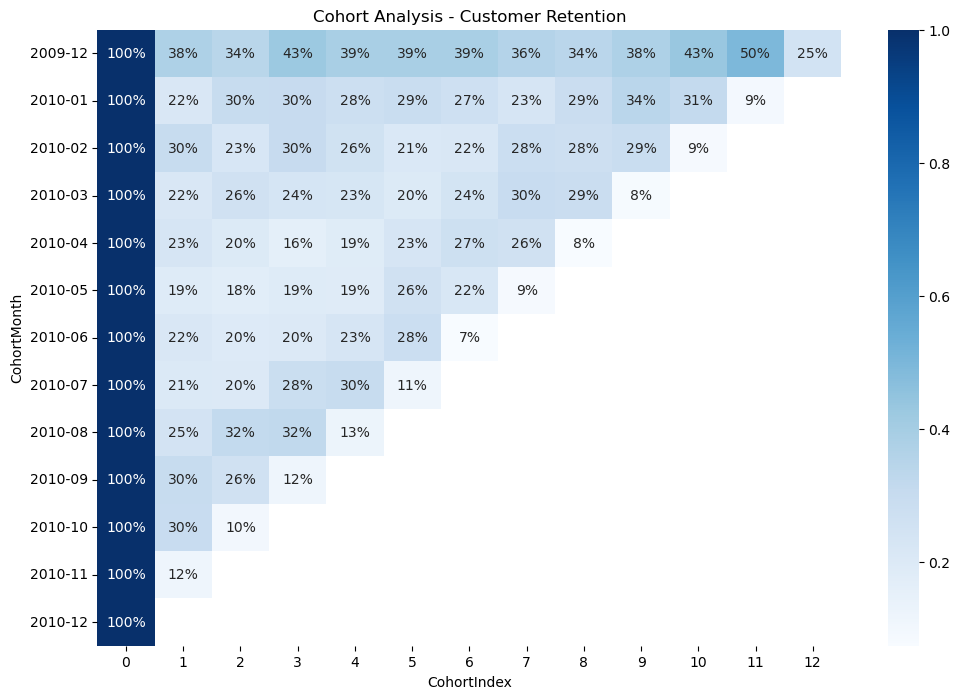

In [35]:
# Plot
plt.figure(figsize=(12,8))
sns.heatmap(cohort_pivot, annot=True, fmt='.0%', cmap='Blues')
plt.title('Cohort Analysis - Customer Retention')
plt.show()

In [36]:
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,InvoiceMonth,CohortMonth,CohortIndex
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12,2009-12,0
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12,2009-12,0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12,2009-12,0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12,2009-12,0
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12,2009-12,0


In [37]:
monetary = data.groupby('Customer ID')['TotalPrice'].sum()

# Frequency: number of purchases (unique invoices)
frequency = data.groupby('Customer ID')['Invoice'].nunique()

# Recency: days since last purchase
snapshot_date = data['InvoiceDate'].max() + pd.Timedelta(days=1)
recency = data.groupby('Customer ID')['InvoiceDate'].max().apply(lambda x: (snapshot_date - x).days)

# Tenure: days since first purchase
tenure = data.groupby('Customer ID')['InvoiceDate'].min().apply(lambda x: (snapshot_date - x).days)

# CategoryCount: number of unique product categories purchased
category_count = data.groupby('Customer ID')['StockCode'].nunique()

# Combine into feature table
data = pd.DataFrame({
    'Recency': recency,
    'Frequency': frequency,
    'Monetary': monetary,
    'Tenure': tenure,
    'CategoryCount': category_count
})

# Define churn label (example: no purchase in last 90 days)
data['Churn'] = (data['Recency'] > 90).astype(int)

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

In [39]:
# Features (example)
X = data[['Recency','Frequency','Monetary','Tenure','CategoryCount']]
y = data['Churn']  # 1 = churned, 0 = active

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       896
           1       1.00      1.00      1.00       419

    accuracy                           1.00      1315
   macro avg       1.00      1.00      1.00      1315
weighted avg       1.00      1.00      1.00      1315

ROC-AUC: 1.0


In [77]:
data.head()

,Recency,Frequency,Monetary,Tenure,CategoryCount,Churn
Customer ID,,,,,,
12346.0,67,15,-64.68,361,29,0
12347.0,3,2,1323.32,40,70,0
12348.0,74,1,222.16,74,20,0
12349.0,43,4,2646.99,371,92,0
12351.0,11,1,300.93,11,21,0


In [40]:
data.to_excel('Churn_Dataset.xlsx')

In [41]:
import joblib
joblib.dump(model,'churn_model.pkl')

['churn_model.pkl']